In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np
from plotly.subplots import make_subplots
import plotly.graph_objects as go

torch.manual_seed(12345)

class LinearToyModel(nn.Module):
  # Parameters from the paper: n = 20, m = 5, I_i = 0.7 ** i
  # Note: Some of these parameters differ for certain graphs

  def __init__(self, m=5, n=20, n_batches = 5, feature_probability = 0.3):
    super().__init__()
    self.n_batches = n_batches
    if torch.cuda.is_available():
      self.device = 'cuda'
    else:
      self.device = 'cpu'
    self.feature_probability = feature_probability
    self.n = n
    self.W = nn.Parameter(torch.randn((m,n),device=self.device))
    self.b = nn.Parameter(torch.randn((n,),device=self.device))
    self.i = 0.7 ** torch.arange(self.n)


# Generating a sparse tensor of random values between 0 and 1 where only 10% of values are > 0
  def forward(self, x):
    h = x @ self.W.T # Encoder
    x2 = (h @ self.W) + self.b
    return x2

  def generate_data(self):
    feat = torch.rand(self.n_batches,self.n, device=self.W.device)

    # This is like an if statement.
    # We are making a tensor where each element has 30% chance of showing element from our feat tensor and 70% chance of showing 0

    batch = torch.where(
        torch.rand(self.n_batches,self.n, device=self.W.device) < self.feature_probability,
        feat,
        torch.zeros(self.n_batches,self.n, device=self.W.device),
    )

    return batch

In [2]:

class ReLUToyModel(nn.Module):
  # Parameters from the paper: n = 20, m = 5, I_i = 0.7 ** i
  def __init__(self, m=5, n=20, n_batches = 1024, feature_probability = 0.3):
    super().__init__()
    self.n_batches = n_batches
    if torch.cuda.is_available():
      self.device = 'cuda'
    else:
      self.device = 'cpu'
    self.feature_probability = feature_probability
    self.n = n
    self.W = nn.Parameter(torch.randn((m,n),device = self.device))
    self.b = nn.Parameter(torch.zeros((n,),device = self.device))
    self.i = 0.7 ** torch.arange(n)


# Generating a sparse tensor of random values between 0 and 1 where only 10% of values are > 0
  def forward(self, x):
    h = x @ self.W.T # Encoder. We are multiplying out [n_batch,n_features] tensor by [n_features,n_dimensions] tensor to get [n_batch,n_dimensions]
    nonlin = nn.ReLU()
    x2 = (h @ self.W) + self.b # [n_batch,n_dimensions] tensor by [n_dimensions,n_features] to get [n_batch,n_features]
    return nonlin(x2)

  def generate_data(self):
    feat = torch.rand(self.n_batches,self.n, device=self.W.device)

    # This is like an if statement.
    # We are making a tensor where each element has 30% chance of showing element from our feat tensor and 70% chance of showing 0

    batch = torch.where(
        torch.rand(self.n_batches,self.n, device=self.W.device) < self.feature_probability,
        feat,
        torch.zeros(self.n_batches,self.n, device=self.W.device),
    )

    return batch

In [3]:
def train(model):
  optim = torch.optim.AdamW([model.W, model.b], lr=1e-2)

  for step in range(10000):
    optim.zero_grad()
    batch = model.generate_data()
    out = model(batch)
    loss = (model.i*(batch - out) ** 2).mean()

    loss.backward()
    optim.step()
    if step % 1000 == 0:
      print("loss: ",loss)


In [4]:
# Code for this  mostly taken verbatim from Anthropic's implementation.
# I have decided to only train one model however for simplification

def intro_diagram(model):
  from matplotlib import colors  as mcolors
  from matplotlib import collections  as mc
  WA = model.W.detach()
  plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.viridis(model.i.cpu().numpy()))
  plt.rcParams['figure.dpi'] = 200
  N = len(WA[:,0])
  W = WA.cpu().detach().numpy().T
  fig, ax = plt.subplots(figsize=(2,2))
  colors = [mcolors.to_rgba(c)
            for c in plt.rcParams['axes.prop_cycle'].by_key()['color']]
  ax.scatter(W[:,0], W[:,1], c=colors[0:len(W[:,0])])
  ax.add_collection(mc.LineCollection(np.stack((np.zeros_like(W),W), axis=1), colors=colors))
  z = 1.5
  ax.set_facecolor('#FCFBF8')
  ax.set_xlim((-z,z))
  ax.set_ylim((-z,z))
  ax.tick_params(left = True, right = False , labelleft = False ,
                  labelbottom = False, bottom = True)
  for spine in ['top', 'right']:
      ax.spines[spine].set_visible(False)
  for spine in ['bottom','left']:
      ax.spines[spine].set_position('center')
  plt.show()



loss:  tensor(1.4707, grad_fn=<MeanBackward0>)
loss:  tensor(0.0139, grad_fn=<MeanBackward0>)
loss:  tensor(0.0170, grad_fn=<MeanBackward0>)
loss:  tensor(0.0120, grad_fn=<MeanBackward0>)
loss:  tensor(0.0220, grad_fn=<MeanBackward0>)
loss:  tensor(0.0460, grad_fn=<MeanBackward0>)
loss:  tensor(0.0205, grad_fn=<MeanBackward0>)
loss:  tensor(0.0214, grad_fn=<MeanBackward0>)
loss:  tensor(0.0104, grad_fn=<MeanBackward0>)
loss:  tensor(0.0233, grad_fn=<MeanBackward0>)


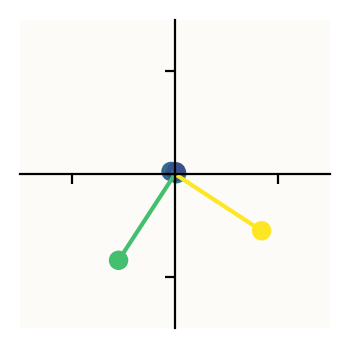

In [5]:
model = LinearToyModel(m=2,n=5)
train(model)
intro_diagram(model)

loss:  tensor(2.9701, grad_fn=<MeanBackward0>)
loss:  tensor(0.0260, grad_fn=<MeanBackward0>)
loss:  tensor(0.0152, grad_fn=<MeanBackward0>)
loss:  tensor(0.0110, grad_fn=<MeanBackward0>)
loss:  tensor(0.0123, grad_fn=<MeanBackward0>)
loss:  tensor(0.0111, grad_fn=<MeanBackward0>)
loss:  tensor(0.0103, grad_fn=<MeanBackward0>)
loss:  tensor(0.0115, grad_fn=<MeanBackward0>)
loss:  tensor(0.0116, grad_fn=<MeanBackward0>)
loss:  tensor(0.0115, grad_fn=<MeanBackward0>)


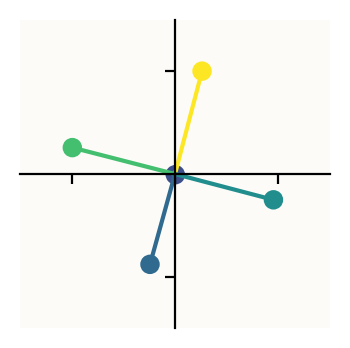

In [6]:
model = ReLUToyModel(n=5,m=2)
train(model)
intro_diagram(model)

In [11]:
def render_features(model):
  W = model.W.detach()
  W_norm = W / (1e-5 + torch.linalg.norm(W,2,dim=0,keepdim=True))

  # Start with 20x5 matrix. Matrix multiply with 5x20 matrix. Get 20x20 matrix
  # This is essentially getting the dot product of each feature so we can see how they interfere
  # Done through this way rather than the einsum way for simplicity. May change later.
  interference = W_norm.T @ W
  interference[torch.arange(model.n),torch.arange(model.n)] = 0 # This code sets the diagonal of our matrix to 0 because these will just be the interference of a feature with itself

  polysemanticity = torch.linalg.norm(interference,2, dim=0).cpu()

  net_interference = (interference **2 * model.feature_probability).sum(-1)
  norms = torch.linalg.norm(W,2,dim=0).cpu()
  WtW = W.T @ W

  x = torch.arange(model.n)

  # Like with the last graph, my implementation is significantly simplified due to only including one model
  # Again, a lot of this code it taken verbatim from Anthropic's implementation so I can get similar graphs
  fig = make_subplots(rows=2, cols=1)
  fig.add_trace(
    go.Bar(x=x, y=norms, marker=dict(color=polysemanticity,cmin=0,cmax=1),width = 0.9), row=1, col=1
  )
  data = WtW.numpy()
  fig.add_trace(
     go.Image(
            z=plt.cm.coolwarm((1 + data)/2, bytes=True),
            colormodel='rgba256',
            customdata=data,
            hovertemplate='''\
  In: %{x}<br>
  Out: %{y}<br>
  Weight: %{customdata:0.2f}
  ''' ),row=2, col=1,)
  fig.add_vline(
    x=(x[model.W.shape[0]-1] + x[model.W.shape[0]]) / 2,
    line=dict(width=0.5),
    col=1,
)
  fig.update_layout(showlegend=False,
                    width=600,
                    height=600,
                    margin=dict(t=0, b=0))
  fig.update_xaxes(visible=False)
  fig.update_yaxes(visible=False)
  return fig


In [12]:
model = ReLUToyModel(m=20,n=100, feature_probability= (20 ** -torch.linspace(0, 1, 100)))
train(model)
print(model.W)
fig = render_features(model)
fig.update_layout()

loss:  tensor(9.5900, grad_fn=<MeanBackward0>)
loss:  tensor(0.0130, grad_fn=<MeanBackward0>)
loss:  tensor(0.0106, grad_fn=<MeanBackward0>)
loss:  tensor(0.0069, grad_fn=<MeanBackward0>)
loss:  tensor(0.0044, grad_fn=<MeanBackward0>)
loss:  tensor(0.0010, grad_fn=<MeanBackward0>)
loss:  tensor(0.0005, grad_fn=<MeanBackward0>)
loss:  tensor(0.0003, grad_fn=<MeanBackward0>)
loss:  tensor(0.0002, grad_fn=<MeanBackward0>)
loss:  tensor(0.0001, grad_fn=<MeanBackward0>)
Parameter containing:
tensor([[ 0.0295,  0.1007, -0.1973,  ...,  0.0174, -0.3083, -0.4072],
        [-0.2396,  0.0633,  0.0049,  ...,  0.1557,  0.0631, -0.0398],
        [ 0.1488,  0.2780,  0.4564,  ..., -0.1323, -0.0683,  0.0470],
        ...,
        [ 0.0996, -0.4880, -0.1318,  ..., -0.7065,  0.0687,  0.1597],
        [ 0.1097,  0.0378, -0.1987,  ..., -0.0620, -0.1885, -0.0592],
        [-0.2332,  0.0947,  0.2728,  ...,  0.0993, -0.0322,  0.0929]],
       requires_grad=True)
